# Entity-Aware Financial News Sentiment Classification

Final project for *Natural Language Processing and Text Analytics (KAN-CDSCO1002U)* at CBS.

**Task**: Aspect-Based Sentiment Analysis (ABSA): classify sentiment (positive / negative / neutral) towards a named entity in a financial news headline.
**Dataset**: SEntFiN 1.0 (Sinha et al., 2023), with 10,753 headlines with 14,404 entity-sentiment annotations.
**Models**: TF-IDF + Naive Bayes, TF-IDF + Logistic Regression, VADER, Word2Vec + Logistic Regression, FinBERT, Local LLM, GPT zero-shot.

## Setup

In [ ]:
#%pip install pandas numpy nltk spacy scikit-learn seaborn matplotlib gensim torch transformers
#%pip install 'accelerate>=1.1.0'


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import ast
import sys
import re
import time
import os
from collections import Counter
import pandas as pd
import numpy as np
import nltk
import spacy
import nobodywho
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from transformers import pipeline as hf_pipeline

/Users/axellidvall/Projekt/Group repository/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/axellidvall/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/axellidvall/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/axellidvall/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## 1. Data

We use SEntFiN 1.0 (Sinha et al., 2023), a human-annotated dataset of 10,753 financial news headlines sourced from The Economic Times (2011-2015). Each headline is annotated for one or more named entities (companies, sectors, commodities) with a sentiment label (positive, negative, or neutral) assigned by three independent human annotators using a consensus-driven process.

Because a single headline can mention multiple entities with potentially conflicting sentiments, each entity-sentiment pair is treated as a separate instance. This gives 14,404 instances in total.

The dataset is loaded directly from the official GitHub repository.

In [3]:
df_raw = pd.read_csv('https://raw.githubusercontent.com/pyRis/SEntFiN/main/SEntFiN.csv')

print(f"Headlines: {len(df_raw)}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head(3)

Headlines: 10753
Columns: ['S No.', 'Title', 'Decisions', 'Words']


,S No.,Title,Decisions,Words
0,1,SpiceJet to issue 6.4 crore warrants to promoters,{'SpiceJet': 'neutral'},8
1,2,MMTC Q2 net loss at Rs 10.4 crore,{'MMTC': 'neutral'},8
2,3,"Mid-cap funds can deliver more, stay put: Experts",{'Mid-cap funds': 'positive'},8


### 1.1 Raw Headline Deduplication

Some headlines appear more than once in the raw dataset with different annotations. Headlines with conflicting `Decisions` across duplicate rows are removed entirely, as keeping any one version would be arbitrary. Headlines with identical `Decisions` across duplicate rows are deduplicated to a single row.

In [4]:
# Remove headlines with conflicting annotations entirely
ambiguous_titles = (
    df_raw['Title'].duplicated(keep=False) &
    (df_raw.groupby('Title')['Decisions'].transform('nunique') > 1)
)
n_ambiguous_titles = df_raw[ambiguous_titles]['Title'].nunique()
df_raw = df_raw[~ambiguous_titles].reset_index(drop=True)

# Remove pure duplicate headlines (same Title + same Decisions) — keep one
n_pure_titles = df_raw.duplicated(subset=['Title', 'Decisions']).sum()
df_raw = df_raw.drop_duplicates(subset=['Title', 'Decisions']).reset_index(drop=True)

print(f'Removed {n_ambiguous_titles} headlines with conflicting annotations')
print(f'Removed {n_pure_titles} pure duplicate headlines')
print(f'Remaining raw headlines: {len(df_raw)}')

Removed 12 headlines with conflicting annotations
Removed 55 pure duplicate headlines
Remaining raw headlines: 10674


In [5]:
def parse_decisions(s):
    # ast.literal_eval breaks on apostrophes in entity names (e.g. "Osian's Art Fund")
    # so we match key-value pairs by anchoring on the known sentiment values instead
    return dict(re.findall(r"'([\w\s'&.()\-,/]+)':\s*'(positive|negative|neutral)'", s))

rows = []
for _, row in df_raw.iterrows():
    decisions = parse_decisions(row['Decisions'])
    for entity, sentiment in decisions.items():
        rows.append({
            'headline': row['Title'],
            'entity': entity,
            'sentiment': sentiment
        })

df = pd.DataFrame(rows)
print(f"Total instances: {len(df)}")
print(f"Unique headlines: {df['headline'].nunique()}")
print(f"Multi-entity headlines: {(df_raw['Decisions'].apply(lambda x: len(parse_decisions(x))) > 1).sum()}")
df.head()

Total instances: 14305
Unique headlines: 10674
Multi-entity headlines: 2830


,headline,entity,sentiment
0,SpiceJet to issue 6.4 crore warrants to promoters,SpiceJet,neutral
1,MMTC Q2 net loss at Rs 10.4 crore,MMTC,neutral
2,"Mid-cap funds can deliver more, stay put: Experts",Mid-cap funds,positive
3,Mid caps now turn into market darlings,Mid caps,positive
4,"Market seeing patience, if not conviction: Pra...",Market,neutral


sentiment
neutral     5447
positive    5046
negative    3792
Name: count, dtype: int64

Total instances: 14285


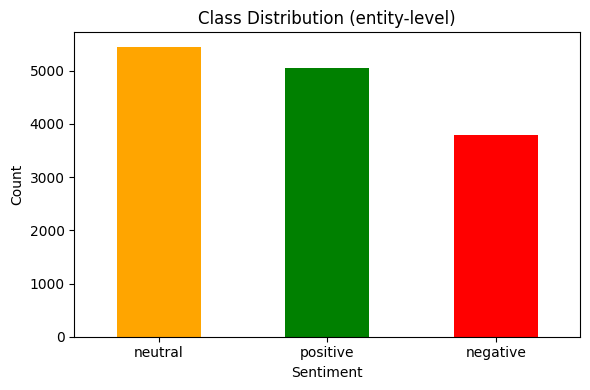

In [14]:
print(df['sentiment'].value_counts())
print(f"\nTotal instances: {len(df)}")

color_map = {'positive': 'green', 'negative': 'red', 'neutral': 'orange'}
counts = df['sentiment'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color=[color_map[l] for l in counts.index])
ax.set_title('Class Distribution (entity-level)')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### Data Cleaning

Check that each annotated entity actually appears in its headline. Rows where the entity cannot be found are likely annotation errors and will be flagged and removed before preprocessing.

In [7]:
# Some annotated entities do not appear in their headline due to annotation errors
# (e.g. 'L&T Finance neutralings' instead of 'L&T Finance Holdings').
# These rows are dropped as the substitution step cannot locate the entity in the text.
df['entity_in_headline'] = df.apply(
    lambda row: row['entity'].lower() in row['headline'].lower(), axis=1
)

flagged = df[~df['entity_in_headline']]
print(f"Removed {len(flagged)} rows where entity not found in headline ({len(flagged)/len(df):.1%})")

df = df[df['entity_in_headline']].drop(columns='entity_in_headline').reset_index(drop=True)
print(f"Remaining instances: {len(df)}")

Removed 20 rows where entity not found in headline (0.1%)
Remaining instances: 14285


### 1.3 Duplicate Removal

Some (headline, entity) pairs appear more than once in the dataset. Ambiguous duplicates (same headline and entity but conflicting sentiment annotations) are removed entirely since there is no ground truth to prefer. Pure duplicates (identical on all three columns) are deduplicated to one instance.

In [8]:
dupes = df[df.duplicated(subset=['headline', 'entity'], keep=False)]
dupes_sorted = dupes.sort_values(['headline', 'entity'])

print(f'Total duplicate instances: {len(dupes_sorted)}')
print()

print('--- Ambiguous (conflicting annotations) ---')
ambiguous = dupes_sorted.groupby(['headline', 'entity']).filter(lambda x: x['sentiment'].nunique() > 1)
print(ambiguous[['headline', 'entity', 'sentiment']].to_string(index=False))
print()

print('--- Pure duplicates (identical rows) ---')
pure = dupes_sorted.groupby(['headline', 'entity']).filter(lambda x: x['sentiment'].nunique() == 1)
print(pure[['headline', 'entity', 'sentiment']].to_string(index=False))

Total duplicate instances: 0

--- Ambiguous (conflicting annotations) ---
Empty DataFrame
Columns: [headline, entity, sentiment]
Index: []

--- Pure duplicates (identical rows) ---
Empty DataFrame
Columns: [headline, entity, sentiment]
Index: []


In [9]:
# Ambiguous duplicates: same headline + entity, conflicting sentiments → remove both
ambiguous_mask = df.groupby(['headline', 'entity'])['sentiment'].transform('nunique') > 1
n_ambiguous = ambiguous_mask.sum()
df = df[~ambiguous_mask].reset_index(drop=True)

# Pure duplicates: same headline + entity + sentiment → keep one
n_pure = df.duplicated(subset=['headline', 'entity', 'sentiment']).sum()
df = df.drop_duplicates(subset=['headline', 'entity', 'sentiment']).reset_index(drop=True)

print(f'Removed {n_ambiguous} ambiguous duplicate instances (conflicting annotations)')
print(f'Removed {n_pure} pure duplicate instances (kept one copy each)')
print(f'Remaining instances: {len(df)}')

Removed 0 ambiguous duplicate instances (conflicting annotations)
Removed 0 pure duplicate instances (kept one copy each)
Remaining instances: 14285


In [10]:
# Headlines with single vs multiple entities
n_entities_per_headline = df.groupby('headline')['entity'].count()
single_headlines = (n_entities_per_headline == 1).sum()
multi_headlines  = (n_entities_per_headline  > 1).sum()
total_headlines  = len(n_entities_per_headline)

# Instances per group
single_df = df[df['headline'].isin(n_entities_per_headline[n_entities_per_headline == 1].index)]
multi_df  = df[df['headline'].isin(n_entities_per_headline[n_entities_per_headline  > 1].index)]

# Average sentence length (words)
avg_len_single = single_df['headline'].apply(lambda x: len(x.split())).mean()
avg_len_multi  = multi_df['headline'].apply(lambda x: len(x.split())).mean()
avg_len_total  = df['headline'].apply(lambda x: len(x.split())).mean()

# Sentiment counts per group
def sent_counts(d):
    counts = d['sentiment'].value_counts()
    total  = len(d)
    pos = counts.get('positive', 0)
    neg = counts.get('negative', 0)
    neu = counts.get('neutral',  0)
    return pos, neg, neu, total

s_pos, s_neg, s_neu, s_tot = sent_counts(single_df)
m_pos, m_neg, m_neu, m_tot = sent_counts(multi_df)
t_pos, t_neg, t_neu, t_tot = sent_counts(df)

print(f"{'':16} {'Headlines':>10}  {'Avg Len':>7}  {'Positive':>16}  {'Negative':>16}  {'Neutral':>16}  {'Overall':>8}")
print(f"{'Single Entity':<16} {single_headlines:>10}  {avg_len_single:>7.2f}  {s_pos:>6} ({s_pos/s_tot:.2%})  {s_neg:>6} ({s_neg/s_tot:.2%})  {s_neu:>6} ({s_neu/s_tot:.2%})  {s_tot:>8}")
print(f"{'Multiple Entity':<16} {multi_headlines:>10}  {avg_len_multi:>7.2f}  {m_pos:>6} ({m_pos/m_tot:.2%})  {m_neg:>6} ({m_neg/m_tot:.2%})  {m_neu:>6} ({m_neu/m_tot:.2%})  {m_tot:>8}")
print(f"{'Overall':<16} {total_headlines:>10}  {avg_len_total:>7.2f}  {t_pos:>6} ({t_pos/t_tot:.2%})  {t_neg:>6} ({t_neg/t_tot:.2%})  {t_neu:>6} ({t_neu/t_tot:.2%})  {t_tot:>8}")


                  Headlines  Avg Len          Positive          Negative           Neutral   Overall
Single Entity          7836     9.74    2825 (36.05%)    2361 (30.13%)    2650 (33.82%)      7836
Multiple Entity        2824    10.50    2221 (34.44%)    1431 (22.19%)    2797 (43.37%)      6449
Overall               10660    10.08    5046 (35.32%)    3792 (26.55%)    5447 (38.13%)     14285


## 2. Preprocessing

### 2.1 Named Entity Recognition

We use spaCy NER to detect entity spans in raw headlines. The dataset annotations serve only as ground truth labels (y); they are not used to guide entity detection. This keeps the pipeline applicable to any unseen headline.

In [11]:
#!python -m spacy download en_core_web_lg

nlp = spacy.load("en_core_web_lg")

# Run NER on all unique headlines in one pass
unique_headlines = df_raw['Title'].tolist()
headline_to_ents = {}
for doc in nlp.pipe(unique_headlines, batch_size=64):
    headline_to_ents[doc.text] = [ent.text for ent in doc.ents]

total_detected = sum(len(v) for v in headline_to_ents.values())
headlines_with_ents = sum(1 for v in headline_to_ents.values() if len(v) > 0)
print(f"Headlines processed: {len(unique_headlines)}")
print(f"Headlines with at least one entity detected: {headlines_with_ents} ({headlines_with_ents/len(unique_headlines):.1%})")
print(f"Total entity spans detected: {total_detected}")

# Match rate: annotated entity found in spaCy detections
matched = sum(
    1 for _, row in df.iterrows()
    if any(row['entity'].lower() in d.lower() or d.lower() in row['entity'].lower()
           for d in headline_to_ents.get(row['headline'], []))
)
print(f"spaCy matched {matched}/{len(df)} annotated entities ({matched/len(df):.1%})")

Headlines processed: 10674
Headlines with at least one entity detected: 9656 (90.5%)
Total entity spans detected: 19865
spaCy matched 9266/14285 annotated entities (64.9%)


### 2.2 Sanity Check: spaCy vs Dataset Annotations

For each annotated (headline, entity) pair, we check whether spaCy detected that entity (or a span overlapping it). This measures how much signal is lost due to NER errors before we commit to using spaCy detections for substitution.

In [12]:
def entity_matched(annotated, detected_list):
    """True if annotated entity overlaps (substring) with any detected span."""
    a = annotated.lower().strip()
    return any(a in d.lower() or d.lower() in a for d in detected_list)

# Recall: of all annotated entities, how many did spaCy find?
matched = 0
missed = []
for _, row in df.iterrows():
    detected = headline_to_ents.get(row['headline'], [])
    if entity_matched(row['entity'], detected):
        matched += 1
    else:
        missed.append((row['headline'], row['entity'], detected))

recall = matched / len(df)

# Precision: of all spaCy detections, how many match the entity column in df?
# Count detections per unique headline to avoid inflating with multi-entity rows
entities_by_headline = df.groupby('headline')['entity'].apply(list).to_dict()

correct_detections = 0
total_detections = 0
for headline, detected_list in headline_to_ents.items():
    annotated_list = [e.lower() for e in entities_by_headline.get(headline, [])]
    for detected in detected_list:
        total_detections += 1
        d = detected.lower()
        if any(a in d or d in a for a in annotated_list):
            correct_detections += 1

precision = correct_detections / total_detections if total_detections > 0 else 0

print(f"Recall:    {matched}/{len(df)} ({recall:.1%}) — annotated entities found by spaCy")
print(f"Precision: {correct_detections}/{total_detections} ({precision:.1%}) — spaCy detections matching the entity column in df")
print(f"Missed: {len(missed)}")

print("\nSample missed cases (headline | annotated entity | spaCy detected):")
for headline, entity, detected in missed[:10]:
    print(f"  '{headline}'\n  annotated: '{entity}' | detected: {detected}\n")

Recall:    9266/14285 (64.9%) — annotated entities found by spaCy
Precision: 9275/19865 (46.7%) — spaCy detections matching the entity column in df
Missed: 5019

Sample missed cases (headline | annotated entity | spaCy detected):
  'Mid-cap funds can deliver more, stay put: Experts'
  annotated: 'Mid-cap funds' | detected: []

  'Mid caps now turn into market darlings'
  annotated: 'Mid caps' | detected: []

  'Market seeing patience, if not conviction: Prakash Diwan'
  annotated: 'Market' | detected: ['Prakash Diwan']

  'HOEC could retest 30-35 levels: Ashwani Gujral'
  annotated: 'HOEC' | detected: ['30-35', 'Ashwani Gujral']

  'Gold shines on seasonal demand; Silver dull'
  annotated: 'Gold' | detected: []

  'Gold shines on seasonal demand; Silver dull'
  annotated: 'Silver' | detected: []

  'Would stick to banking: Girish Pai, Centrum Broking'
  annotated: 'banking' | detected: ['Girish Pai', 'Centrum Broking']

  'US stocks finish mixed amid more tech selling'
  annotated: 'te

### 2.3 Target/Other Substitution via String Matching

spaCy NER reached only 64.7% recall because commodities, sectors, and generic financial terms fall outside standard NER categories. We instead locate entities using case-insensitive string matching against the annotated entity names, giving 100% coverage across all entity types.

For each instance (headline, focal entity), the focal entity is replaced with `Target` and all other entities in the same headline are replaced with `Other`. Entities are sorted longest-first before substitution so shorter prefixes (e.g. `Alstom`) do not shadow longer names (e.g. `Alstom India`). A left-word-boundary lookbehind (`(?<!\w)`) prevents short entities like `GE` or `ET` from matching as substrings inside common words or inside an already-placed token, while still matching possessive prefix forms such as `Sebis` (entity `Sebi`).

In [13]:
entities_by_headline = df.groupby('headline')['entity'].apply(list).to_dict()

def substitute_entities(headline, focal_entity, all_entities):
    # Sort longest first to prevent shorter entities matching inside longer ones
    sorted_entities = sorted(all_entities, key=len, reverse=True)
    text = headline
    for entity in sorted_entities:
        replacement = 'Target' if entity.lower() == focal_entity.lower() else 'Other'
        text = re.sub(re.escape(entity), replacement, text, flags=re.IGNORECASE)
    return text

df['substituted'] = df.apply(
    lambda row: substitute_entities(
        row['headline'],
        row['entity'],
        entities_by_headline[row['headline']]
    ),
    axis=1
)

print("\nSample substitutions:")
for _, row in df.head(8).iterrows():
    print(f"  original:     '{row['headline']}'")
    print(f"  entity:       '{row['entity']}'")
    print(f"  substituted:  '{row['substituted']}'")
    print()



Sample substitutions:
  original:     'SpiceJet to issue 6.4 crore warrants to promoters'
  entity:       'SpiceJet'
  substituted:  'Target to issue 6.4 crore warrants to promoters'

  original:     'MMTC Q2 net loss at Rs 10.4 crore'
  entity:       'MMTC'
  substituted:  'Target Q2 net loss at Rs 10.4 crore'

  original:     'Mid-cap funds can deliver more, stay put: Experts'
  entity:       'Mid-cap funds'
  substituted:  'Target can deliver more, stay put: Experts'

  original:     'Mid caps now turn into market darlings'
  entity:       'Mid caps'
  substituted:  'Target now turn into market darlings'

  original:     'Market seeing patience, if not conviction: Prakash Diwan'
  entity:       'Market'
  substituted:  'Target seeing patience, if not conviction: Prakash Diwan'

  original:     'Infosys: Will the strong volume growth sustain?'
  entity:       'Infosys'
  substituted:  'Target: Will the strong volume growth sustain?'

  original:     'Hudco raises Rs 279 cr via tax-f

### 2.4 Tokenization and Punctuation Removal

Lowercase, tokenize with `word_tokenize`, and remove non-alphabetic tokens. Stop words are kept, as the paper does not remove them for lexicon-based and BoW models.

In [81]:
def preprocess(text):                                                    
    tokens = word_tokenize(text)
    return ' '.join(t for t in tokens if t.isalnum() or                  
                re.match(r'^\d+\.\d+$', t))  

df['processed'] = df['substituted'].apply(preprocess)

print("Sample:")
for _, row in df.head(5).iterrows():
    print(f"  substituted: '{row['substituted']}'")
    print(f"  processed:   '{row['processed']}'")
    print() 

Sample:
  substituted: 'Target to issue 6.4 crore warrants to promoters'
  processed:   'Target to issue 6.4 crore warrants to promoters'

  substituted: 'Target Q2 net loss at Rs 10.4 crore'
  processed:   'Target Q2 net loss at Rs 10.4 crore'

  substituted: 'Target can deliver more, stay put: Experts'
  processed:   'Target can deliver more stay put Experts'

  substituted: 'Target now turn into market darlings'
  processed:   'Target now turn into market darlings'

  substituted: 'Target seeing patience, if not conviction: Prakash Diwan'
  processed:   'Target seeing patience if not conviction Prakash Diwan'



### 2.5 Train/Test Split

Headline-level 80/20 split using `GroupShuffleSplit`. All instances from a given headline go entirely to train or entirely to test, preventing data leakage where the same headline could appear in both splits for different entities.

In [82]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, df['sentiment'], groups=df['headline']))

X_train = df['processed'].iloc[train_idx]
X_test  = df['processed'].iloc[test_idx]
y_train = df['sentiment'].iloc[train_idx]
y_test  = df['sentiment'].iloc[test_idx]

train_sentences = [text.split() for text in X_train]
test_sentences  = [text.split() for text in X_test]

# Raw headlines and entity names aligned with test split — used by LLM models
test_df      = df.loc[X_test.index, ['headline', 'entity']].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Sanity check: no headline in both splits
assert len(set(df['headline'].iloc[train_idx]) & set(df['headline'].iloc[test_idx])) == 0

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"\nClass distribution — train:\n{y_train.value_counts()}")
print(f"\nClass distribution — test:\n{y_test.value_counts()}")


Train: 11462 | Test: 2823

Class distribution — train:
sentiment
neutral     4336
positive    4064
negative    3062
Name: count, dtype: int64

Class distribution — test:
sentiment
neutral     1111
positive     982
negative     730
Name: count, dtype: int64


## 3. Models

All models receive the Target/Other substituted headline as input and are evaluated on the same 80/20 test split. Primary metric is macro F1.

A shared evaluation helper is defined once and reused across all models.

In [110]:
def evaluate(name, y_true, y_pred):
    print(f"=== {name} ===")
    print(classification_report(y_true, y_pred, target_names=['negative', 'neutral', 'positive']))
    cm = confusion_matrix(y_true, y_pred, labels=['negative', 'neutral', 'positive'])
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['negative', 'neutral', 'positive'],
                yticklabels=['negative', 'neutral', 'positive'], ax=ax)
    ax.set_title(f'{name} — confusion matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

def error_analysis(name, y_true, y_pred, headlines, entities, n=5):
    y_true     = list(y_true)
    y_pred     = list(y_pred)
    headlines  = list(headlines)
    entities   = list(entities)
    classes    = ['negative', 'neutral', 'positive']

    print(f"=== {name} — Error Analysis ===\n")

    # Misclassified examples
    print(f"\nSample misclassified headlines (up to {n} per error type):")
    for true_cls in classes:
        for pred_cls in classes:
            if true_cls == pred_cls:
                continue
            examples = [(headlines[i], entities[i], y_true[i], y_pred[i])
                        for i in range(len(y_true))
                        if y_true[i] == true_cls and y_pred[i] == pred_cls]
            if not examples:
                continue
            print(f"\n  true={true_cls} → predicted={pred_cls} ({len(examples)} cases):")
            for h, e, t, p in examples[:n]:
                print(f"    '{h}'  (entity: {e})")


### 3.1 VADER

Lexicon-based baseline. Runs on the substituted headline text (not tokenized; VADER expects natural language). Compound score mapped to sentiment classes using standard thresholds: >= 0.05 positive, <= -0.05 negative, otherwise neutral.

=== VADER ===
              precision    recall  f1-score   support

    negative       0.59      0.43      0.50       730
     neutral       0.52      0.66      0.58      1111
    positive       0.56      0.51      0.53       982

    accuracy                           0.55      2823
   macro avg       0.56      0.53      0.54      2823
weighted avg       0.55      0.55      0.54      2823



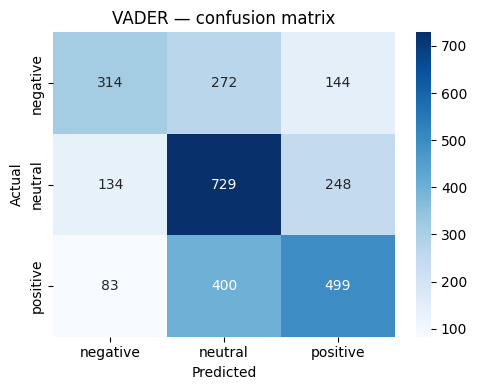

In [84]:
sia = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# VADER runs on substituted text, aligned with the test split index
X_test_raw = df.loc[X_test.index, 'substituted']
y_pred_vader = X_test_raw.apply(vader_predict)

evaluate('VADER', y_test, y_pred_vader)

In [111]:
error_analysis('VADER', y_test, y_pred_vader, df.loc[X_test.index, 'headline'].reset_index(drop=True), df.loc[X_test.index, 'entity'].reset_index(drop=True))

=== VADER — Error Analysis ===


Sample misclassified headlines (up to 5 per error type):

  true=negative → predicted=neutral (272 cases):
    'SREI Infra is moving sideways: Ashwani Gujral, Market Strategist'  (entity: SREI Infra)
    'Immediate resistance for Reliance is around 1018, 1048 levels: Mileen Vasudeo, Angel Broking'  (entity: Reliance)
    'World stock markets slip as buying fervor cools'  (entity: World stock markets)
    'Silver falls 0.55% on profit-booking, global cues'  (entity: Silver)
    'Four reasons Sensex tanked over 400 points intraday'  (entity: Sensex)

  true=negative → predicted=positive (144 cases):
    'Immediate support for rupee is placed at 55.10: Bonanza'  (entity: rupee)
    'Large-caps better than mid-caps IT cos: Prateek Agarwal'  (entity: mid-caps IT cos)
    'Germany's DAX outperforms European shares after strong data'  (entity: European shares)
    'British pound slips against buoyant Fed-boosted dollar'  (entity: British pound)
    'Tulip Tele

### 3.2 TF-IDF + Naive Bayes

Unigrams, bigrams, and trigrams. Fit on training set only.

=== TF-IDF + Naive Bayes ===
              precision    recall  f1-score   support

    negative       0.84      0.56      0.67       730
     neutral       0.74      0.79      0.76      1111
    positive       0.72      0.85      0.78       982

    accuracy                           0.75      2823
   macro avg       0.77      0.73      0.74      2823
weighted avg       0.76      0.75      0.74      2823



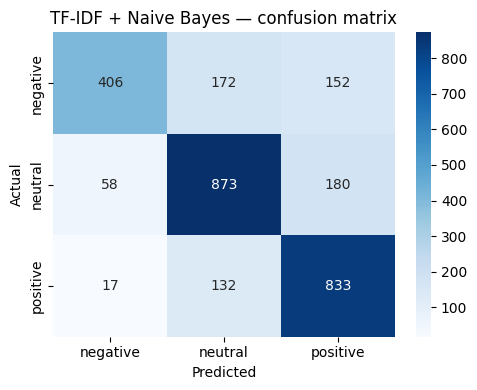

In [85]:
tfidf = TfidfVectorizer(ngram_range=(1, 3))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

evaluate('TF-IDF + Naive Bayes', y_test, y_pred_nb)

In [112]:
error_analysis('TF-IDF + Naive Bayes', y_test, y_pred_nb, df.loc[X_test.index, 'headline'].reset_index(drop=True), df.loc[X_test.index, 'entity'].reset_index(drop=True))

=== TF-IDF + Naive Bayes — Error Analysis ===


Sample misclassified headlines (up to 5 per error type):

  true=negative → predicted=neutral (172 cases):
    'Immediate support for rupee is placed at 55.10: Bonanza'  (entity: rupee)
    'Foreign investors navigate turmoil in Chinese markets with new playbook'  (entity: Chinese markets)
    'Immediate resistance for Reliance is around 1018, 1048 levels: Mileen Vasudeo, Angel Broking'  (entity: Reliance)
    'Large-caps better than mid-caps IT cos: Prateek Agarwal'  (entity: mid-caps IT cos)
    'Yen plunge hurting, but more still to come'  (entity: Yen)

  true=negative → predicted=positive (152 cases):
    'SREI Infra is moving sideways: Ashwani Gujral, Market Strategist'  (entity: SREI Infra)
    'Be cautious on amount of stock you buy into BEML: Devang Visaria'  (entity: BEML)
    'Dollar hits 6-year high vs yen on Fed study, sterling woes continue'  (entity: sterling)
    'Germany's DAX outperforms European shares after strong data

### 3.3 TF-IDF + Logistic Regression

Same TF-IDF features as Naive Bayes. `max_iter=1000` to ensure convergence.

=== TF-IDF + Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.83      0.68      0.75       730
     neutral       0.77      0.82      0.79      1111
    positive       0.79      0.83      0.81       982

    accuracy                           0.79      2823
   macro avg       0.80      0.78      0.78      2823
weighted avg       0.79      0.79      0.79      2823



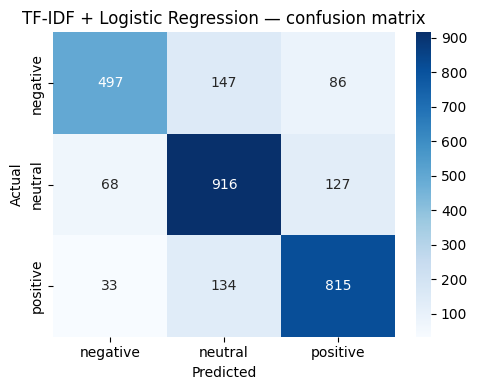

In [86]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

evaluate('TF-IDF + Logistic Regression', y_test, y_pred_lr)

In [113]:
error_analysis('TF-IDF + Logistic Regression', y_test, y_pred_lr, df.loc[X_test.index, 'headline'].reset_index(drop=True), df.loc[X_test.index, 'entity'].reset_index(drop=True))

=== TF-IDF + Logistic Regression — Error Analysis ===


Sample misclassified headlines (up to 5 per error type):

  true=negative → predicted=neutral (147 cases):
    'Immediate support for rupee is placed at 55.10: Bonanza'  (entity: rupee)
    'Foreign investors navigate turmoil in Chinese markets with new playbook'  (entity: Chinese markets)
    'Immediate resistance for Reliance is around 1018, 1048 levels: Mileen Vasudeo, Angel Broking'  (entity: Reliance)
    'Large-caps better than mid-caps IT cos: Prateek Agarwal'  (entity: mid-caps IT cos)
    'Spurt in LNG prices, under-utilisation, to hurt Petronet'  (entity: Petronet)

  true=negative → predicted=positive (86 cases):
    'SREI Infra is moving sideways: Ashwani Gujral, Market Strategist'  (entity: SREI Infra)
    'Be cautious on amount of stock you buy into BEML: Devang Visaria'  (entity: BEML)
    'Dollar hits 6-year high vs yen on Fed study, sterling woes continue'  (entity: sterling)
    'Germany's DAX outperforms Europea

### 3.4 Word2Vec + Logistic Regression

Word2Vec is trained on the training set only, producing a dense vector for each word. Each headline is represented as the average of its word vectors (average pooling). Headlines with no words in the vocabulary are represented as a zero vector. The averaged vectors are fed into Logistic Regression.

This captures semantic similarity between words ("profit" and "gain" end up close in vector space), which TF-IDF cannot. However, averaging loses word order, so "Target beats Other" and "Other beats Target" map to the same vector. The paper uses GloVe+LSTM, which preserves order; our approach is a simpler in-scope analogue.

=== Word2Vec + Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.52      0.22      0.31       730
     neutral       0.50      0.71      0.59      1111
    positive       0.45      0.43      0.44       982

    accuracy                           0.49      2823
   macro avg       0.49      0.46      0.45      2823
weighted avg       0.49      0.49      0.47      2823



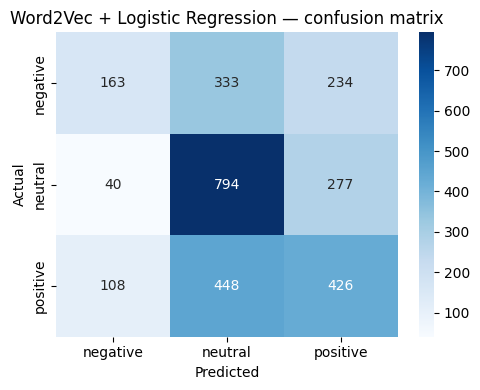

In [87]:
w2v = Word2Vec(sentences=train_sentences, vector_size=100, window=5, min_count=1, workers=4, seed=42)

def avg_feature_vector(words, model, vector_size):
    vecs = [model.wv[w] for w in words if w in model.wv]
    if not vecs:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0)

X_train_w2v = np.array([avg_feature_vector(s, w2v, 100) for s in train_sentences])
X_test_w2v  = np.array([avg_feature_vector(s, w2v, 100) for s in test_sentences])

lr_w2v = LogisticRegression(max_iter=1000)
lr_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = lr_w2v.predict(X_test_w2v)

evaluate('Word2Vec + Logistic Regression', y_test, y_pred_w2v)

In [114]:
error_analysis('Word2Vec + LR', y_test, y_pred_w2v, df.loc[X_test.index, 'headline'].reset_index(drop=True), df.loc[X_test.index, 'entity'].reset_index(drop=True))

=== Word2Vec + LR — Error Analysis ===


Sample misclassified headlines (up to 5 per error type):

  true=negative → predicted=neutral (333 cases):
    'Why Chinese stocks leave US investors vulnerable'  (entity: US)
    'Immediate support for rupee is placed at 55.10: Bonanza'  (entity: rupee)
    'SREI Infra is moving sideways: Ashwani Gujral, Market Strategist'  (entity: SREI Infra)
    'Foreign investors navigate turmoil in Chinese markets with new playbook'  (entity: Chinese markets)
    'Be cautious on amount of stock you buy into BEML: Devang Visaria'  (entity: BEML)

  true=negative → predicted=positive (234 cases):
    'Dollar hits 6-year high vs yen on Fed study, sterling woes continue'  (entity: sterling)
    'Germany's DAX outperforms European shares after strong data'  (entity: European shares)
    'British pound slips against buoyant Fed-boosted dollar'  (entity: British pound)
    'South Korean shares briefly dip to 2-month low'  (entity: South Korean shares)
    'Four r

### 3.5 GloVe + Logistic Regression

Same average-pooling approach as Word2Vec, but using Stanford's pre-trained GloVe vectors (6B tokens, 100d) instead of vectors trained on this corpus. Pre-trained vectors capture richer semantic relationships because they were trained on a much larger and more varied corpus.

The technique (averaged embeddings + LR) is the same as section 4.4 and is used in the course notebooks (E6). The pre-trained vectors are outside course scope and flagged below.

In [ ]:
glove_path = 'glove/glove.6B/glove.6B.100d.txt'
if os.path.exists(glove_path):
    print(f"Found {glove_path}")
else:
    print(f"File not found at {glove_path} — check the folder structure")

Found glove/glove.6B/glove.6B.100d.txt


GloVe vocabulary size: 400,000
=== GloVe + Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.64      0.55      0.59       730
     neutral       0.65      0.69      0.67      1111
    positive       0.62      0.64      0.63       982

    accuracy                           0.64      2823
   macro avg       0.63      0.63      0.63      2823
weighted avg       0.64      0.64      0.63      2823



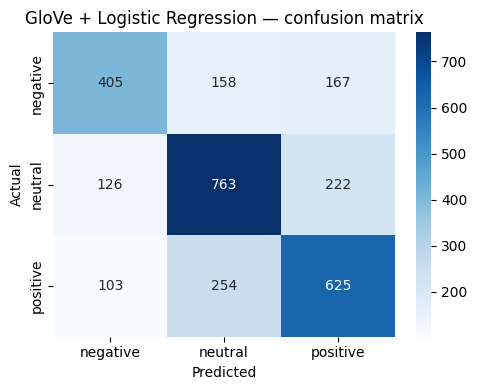

In [89]:
glove = {}
with open('glove/glove.6B/glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        glove[parts[0]] = np.array(parts[1:], dtype=np.float32)

print(f"GloVe vocabulary size: {len(glove):,}")

def avg_glove_vector(words, glove, vector_size=100):
    vecs = [glove[w.lower()] for w in words if w.lower() in glove]
    if not vecs:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0)

X_train_glove = np.array([avg_glove_vector(s, glove) for s in train_sentences])
X_test_glove  = np.array([avg_glove_vector(s, glove) for s in test_sentences])

lr_glove = LogisticRegression(max_iter=1000)
lr_glove.fit(X_train_glove, y_train)
y_pred_glove = lr_glove.predict(X_test_glove)

evaluate('GloVe + Logistic Regression', y_test, y_pred_glove)

In [115]:
error_analysis('GloVe + LR', y_test, y_pred_glove, df.loc[X_test.index, 'headline'].reset_index(drop=True), df.loc[X_test.index, 'entity'].reset_index(drop=True))

=== GloVe + LR — Error Analysis ===


Sample misclassified headlines (up to 5 per error type):

  true=negative → predicted=neutral (158 cases):
    'Immediate support for rupee is placed at 55.10: Bonanza'  (entity: rupee)
    'Foreign investors navigate turmoil in Chinese markets with new playbook'  (entity: Chinese markets)
    'Immediate resistance for Reliance is around 1018, 1048 levels: Mileen Vasudeo, Angel Broking'  (entity: Reliance)
    'Silver weakens in futures trade on global cues'  (entity: Silver)
    'S&P 500 posts biggest weekly decline since 2012'  (entity: S&P 500)

  true=negative → predicted=positive (167 cases):
    'SREI Infra is moving sideways: Ashwani Gujral, Market Strategist'  (entity: SREI Infra)
    'Dollar hits 6-year high vs yen on Fed study, sterling woes continue'  (entity: sterling)
    'Large-caps better than mid-caps IT cos: Prateek Agarwal'  (entity: mid-caps IT cos)
    'World stock markets slip as buying fervor cools'  (entity: World stock marke

## 4. Extended Models (Outside Course Scope)

The following models go beyond the course toolset. They are included to benchmark domain-specific pretraining (FinBERT), frontier LLM zero-shot capability (GPT-5 mini), and local open-weight LLM inference (Qwen3-4B via NobodyWho) against the supervised baselines above.

### 4.6 GPT Zero-Shot (Frontier LLM)

Entity-aware zero-shot classification using the OpenAI API. The raw headline and entity name are passed directly in the prompt, without Target/Other substitution. The model is asked to output exactly one word. This tests whether a frontier LLM can perform entity-aware sentiment classification from a natural-language instruction alone, without any training or feature engineering.

In [ ]:
#%pip install openai -q

import openai

# Set your API key here
OPENAI_API_KEY = "Replace"
client = openai.OpenAI(api_key=OPENAI_API_KEY)


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


GPT: 100%|██████████| 2823/2823 [2:23:56<00:00,  3.06s/it]    

=== GPT Zero-Shot ===
              precision    recall  f1-score   support

    negative       0.79      0.93      0.85       730
     neutral       0.90      0.59      0.72      1111
    positive       0.75      0.93      0.83       982

    accuracy                           0.80      2823
   macro avg       0.81      0.82      0.80      2823
weighted avg       0.82      0.80      0.79      2823



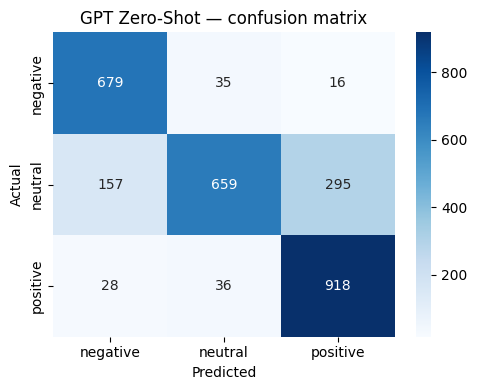

In [94]:
VALID = {'positive', 'negative', 'neutral'}

def gpt_predict(headline, entity, model='gpt-5-mini'):
    prompt = (
        f"Classify the sentiment towards {entity} in this financial news headline "
        f"as exactly one word: positive, negative, or neutral.\n\nHeadline: {headline}"
    )
    response = client.chat.completions.create(
        model=model,
        messages=[{'role': 'user', 'content': prompt}],
    )
    label = response.choices[0].message.content.strip().lower()
    return label if label in VALID else 'neutral'

# Retrieve original headlines and entities aligned with the test split
test_df = df.loc[X_test.index, ['headline', 'entity']].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

from tqdm.auto import tqdm

y_pred_gpt = []
for i, row in tqdm(test_df.iterrows(), total=len(test_df), desc='GPT'):
    y_pred_gpt.append(gpt_predict(row['headline'], row['entity']))
    time.sleep(0.05)

evaluate('GPT Zero-Shot', y_test_reset, y_pred_gpt)

In [116]:
error_analysis('GPT Zero-Shot', y_test_reset, y_pred_gpt, test_df['headline'], test_df['entity'])

=== GPT Zero-Shot — Error Analysis ===


Sample misclassified headlines (up to 5 per error type):

  true=negative → predicted=neutral (35 cases):
    'Immediate support for rupee is placed at 55.10: Bonanza'  (entity: rupee)
    'SREI Infra is moving sideways: Ashwani Gujral, Market Strategist'  (entity: SREI Infra)
    'Immediate resistance for Reliance is around 1018, 1048 levels: Mileen Vasudeo, Angel Broking'  (entity: Reliance)
    'European stocks diverge as markets track Ukraine'  (entity: European stocks)
    'Over 5.6% stake in Dish TV pledged'  (entity: Dish TV)

  true=negative → predicted=positive (16 cases):
    'Bearish soyabean investors loose as market price rise'  (entity: soyabean)
    'CNX IT is out of the sell mode: Mitesh Thacker'  (entity: CNX IT)
    'Slower US jobs growth props up Asia FX, trade data underpins rupiah'  (entity: rupiah)
    'Before swearing-in, stock markets and rupee swear by Narendra Modi'  (entity: rupee)
    'Before swearing-in, stock market

### 4.7 Local LLM Zero-Shot (Qwen3-4B via NobodyWho)

Entity-aware zero-shot classification using a local Qwen3-4B model running via NobodyWho. Same prompt structure as GPT: raw headline and entity name, no Target/Other substitution. Runs fully offline. History is reset between each call to prevent context accumulation.

Tried a range of setups:
option a: "enable_thinking": False, and no attempt at forcing COT in system prompt.
option b: "enable_thinking": False, and an attempt to force COT in system prompt.
option c: "enable_thinking": True, and no attempt to limit reasoning in system prompt.
option d: "enable_thinking": True, and attempting to limit reasoning to 2-3 sentences in system prompt.

Both option c & d resulted in extremly long expected run times which led us to abort the run. Option d managed to cut it down from expected 13 hours to expected 5 hours but it was still deemed to long for this project.

Both option a & b actually got run but option b took 6 times longer to run and yielded a 2% worse accuracy than option a. Worth noting is that option caused the neutal to collapse into positive. When forced to reason, the model seems to interpret ambiguous financial language as optimistic more often than not.


Local LLM: 100%|██████████| 2823/2823 [16:05<00:00,  2.92it/s]

=== Local LLM Zero-Shot (Qwen3-4B) ===
              precision    recall  f1-score   support

    negative       0.68      0.95      0.79       730
     neutral       0.84      0.51      0.63      1111
    positive       0.74      0.85      0.79       982

    accuracy                           0.74      2823
   macro avg       0.75      0.77      0.74      2823
weighted avg       0.76      0.74      0.73      2823



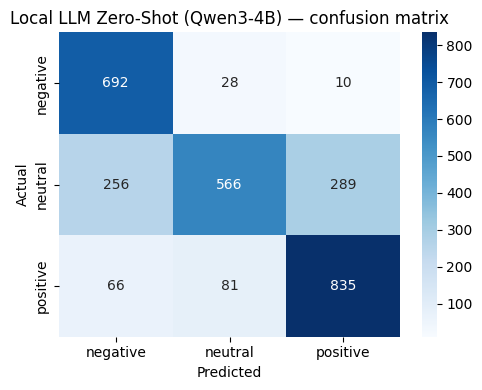

In [95]:
local_chat = nobodywho.Chat(
    "./Qwen_Qwen3-4B-Q4_K_M.gguf",
    #original
    system_prompt="You are a financial sentiment classifier. Classify the sentiment towards a named entity in a financial news headline. Reply with exactly one word: positive, negative, or neutral.",
    #Force shorter reasoning with systemprompt
    #system_prompt="You are a financial sentiment classifier. Classify the sentiment towards a named entity in a financial news headline. Keep your reasoning brief (2-3 sentences maximum) Reply with exactly one word: positive, negative, or neutral.",
    #template_variables={"enable_thinking": True},
    #
    #system_prompt="You are a financial sentiment classifier. Briefly reason about the sentiment towards the named entity (1-2 sentences), then output exactly one word as your final answer: positive, negative, or neutral.",
    template_variables={"enable_thinking": False},
)

VALID_LOCAL = {'positive', 'negative', 'neutral'}

def local_predict(headline, entity):
    local_chat.reset_history()
    prompt = f"What is the sentiment towards {entity} in this headline: positive, negative, or neutral?\n\nHeadline: {headline}"
    response = local_chat.ask(prompt).completed()
    label = response.strip().lower()
    if label in VALID_LOCAL:
        return label
    for v in VALID_LOCAL:
        if v in label:
            return v
    return 'neutral'

from tqdm.auto import tqdm

y_pred_local = []
for i, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Local LLM'):
    y_pred_local.append(local_predict(row['headline'], row['entity']))

evaluate('Local LLM Zero-Shot (Qwen3-4B)', y_test_reset, y_pred_local)

In [117]:
error_analysis('Local LLM Zero-Shot (Qwen3-4B)', y_test_reset, y_pred_local, test_df['headline'], test_df['entity'])

=== Local LLM Zero-Shot (Qwen3-4B) — Error Analysis ===


Sample misclassified headlines (up to 5 per error type):

  true=negative → predicted=neutral (28 cases):
    'SREI Infra is moving sideways: Ashwani Gujral, Market Strategist'  (entity: SREI Infra)
    'Immediate resistance for Reliance is around 1018, 1048 levels: Mileen Vasudeo, Angel Broking'  (entity: Reliance)
    'Gold holds below $1,300 on easing Ukraine concerns'  (entity: Gold)
    'European stocks diverge as markets track Ukraine'  (entity: European stocks)
    'Over 5.6% stake in Dish TV pledged'  (entity: Dish TV)

  true=negative → predicted=positive (10 cases):
    'Germany's DAX outperforms European shares after strong data'  (entity: European shares)
    'Tulip Telecom promoter pledges 23 lakh shares'  (entity: Tulip Telecom)
    'Book profits in PSU banks: Prakash Diwan'  (entity: PSU banks)
    'Slower US jobs growth props up Asia FX, trade data underpins rupiah'  (entity: rupiah)
    'BPCL, HPCL good for sell

### 4.8 FinBERT Zero-Shot

FinBERT (`ProsusAI/finbert`) is a BERT model fine-tuned on financial text for sentiment classification. It receives the Target/Other substituted headline as input, following the same format as all other models and the SEntFiN paper. The model downloads automatically on first run (~440 MB).

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 50325.64it/s]


=== FinBERT Zero-Shot ===
              precision    recall  f1-score   support

    negative       0.72      0.65      0.68       730
     neutral       0.59      0.79      0.67      1111
    positive       0.79      0.54      0.64       982

    accuracy                           0.67      2823
   macro avg       0.70      0.66      0.67      2823
weighted avg       0.69      0.67      0.66      2823



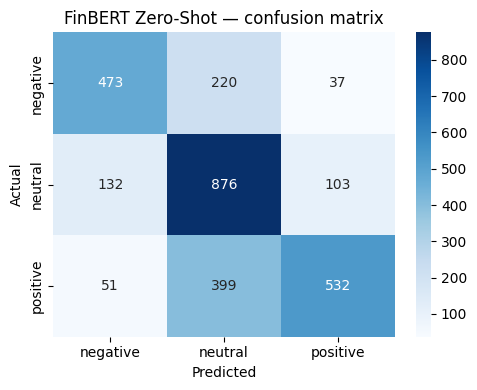

In [ ]:
finbert = hf_pipeline("text-classification", model="ProsusAI/finbert")

# Target/Other substituted inputs
finbert_inputs = df.loc[X_test.index, 'substituted'].reset_index(drop=True).tolist()

raw_preds = finbert(finbert_inputs, batch_size=32, truncation=True)
y_pred_finbert = [p['label'].lower() for p in raw_preds]

evaluate('FinBERT Zero-Shot', y_test, y_pred_finbert)


In [118]:
error_analysis('FinBERT Zero-Shot', y_test, y_pred_finbert, df.loc[X_test.index, 'headline'].reset_index(drop=True), df.loc[X_test.index, 'entity'].reset_index(drop=True))

=== FinBERT Zero-Shot — Error Analysis ===


Sample misclassified headlines (up to 5 per error type):

  true=negative → predicted=neutral (220 cases):
    'Why Chinese stocks leave US investors vulnerable'  (entity: US)
    'Immediate support for rupee is placed at 55.10: Bonanza'  (entity: rupee)
    'SREI Infra is moving sideways: Ashwani Gujral, Market Strategist'  (entity: SREI Infra)
    'Foreign investors navigate turmoil in Chinese markets with new playbook'  (entity: Chinese markets)
    'Be cautious on amount of stock you buy into BEML: Devang Visaria'  (entity: BEML)

  true=negative → predicted=positive (37 cases):
    'Dollar hits 6-year high vs yen on Fed study, sterling woes continue'  (entity: sterling)
    'Germany's DAX outperforms European shares after strong data'  (entity: European shares)
    'Rise in subsidy burden may hit ONGC FPO'  (entity: ONGC)
    'Cardamom prices soften 0.34% on profit-booking'  (entity: Cardamom)
    'Turbulence hits aviation stocks as ref

### 4.9 FinBERT Fine-Tuned

FinBERT (`ProsusAI/finbert`) fine-tuned on the training set using HuggingFace Trainer. Same Target/Other substituted input format as the zero-shot version. Trained for 3 epochs with standard BERT fine-tuning hyperparameters. This turns FinBERT from a zero-shot baseline into a supervised model directly comparable to TF-IDF + LR; the gap between the two FinBERT rows shows how much labelled data is worth on top of domain pre-training.

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 60102.31it/s]
/Users/axellidvall/Projekt/Group repository/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
200,0.601654
400,0.458325
600,0.404355
800,0.321711
1000,0.276488
1200,0.238328
1400,0.239402
1600,0.171320
1800,0.168147
2000,0.168461


=== FinBERT Fine-Tuned ===
              precision    recall  f1-score   support

    negative       0.87      0.89      0.88       730
     neutral       0.89      0.84      0.87      1111
    positive       0.88      0.92      0.90       982

    accuracy                           0.88      2823
   macro avg       0.88      0.88      0.88      2823
weighted avg       0.88      0.88      0.88      2823



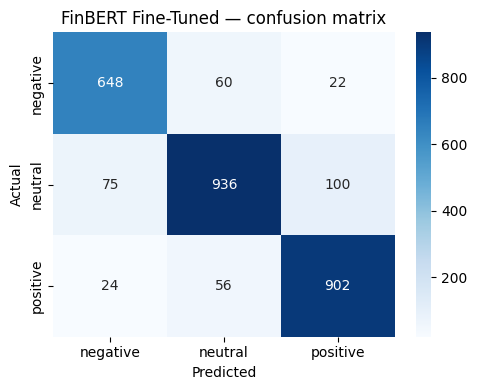

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset
import torch

# Target/Other substituted inputs — same format as the SEntFiN paper
train_inputs_finbert = df.loc[X_train.index, 'substituted'].reset_index(drop=True).tolist()
test_inputs_finbert  = df.loc[X_test.index,  'substituted'].reset_index(drop=True).tolist()

# FinBERT label mapping (from model config)
label2id = {'positive': 0, 'negative': 1, 'neutral': 2}
id2label  = {0: 'positive', 1: 'negative', 2: 'neutral'}

class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

tokenizer_ft = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model_ft     = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

train_enc = tokenizer_ft(train_inputs_finbert, truncation=True, padding=True, max_length=128)
test_enc  = tokenizer_ft(test_inputs_finbert,  truncation=True, padding=True, max_length=128)

train_dataset_ft = SentimentDataset(train_enc, [label2id[l] for l in y_train.reset_index(drop=True)])
test_dataset_ft  = SentimentDataset(test_enc,  [label2id[l] for l in y_test.reset_index(drop=True)])

training_args = TrainingArguments(
    output_dir='./finbert_finetuned',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    save_strategy='no',
    logging_steps=200,
)

trainer = Trainer(
    model=model_ft,
    args=training_args,
    train_dataset=train_dataset_ft,
)

trainer.train()

preds = trainer.predict(test_dataset_ft)
y_pred_finbert_ft = [id2label[p] for p in preds.predictions.argmax(axis=1)]

evaluate('FinBERT Fine-Tuned', y_test, y_pred_finbert_ft)


In [119]:
error_analysis('FinBERT Fine-Tuned', y_test, y_pred_finbert_ft, df.loc[X_test.index, 'headline'].reset_index(drop=True), df.loc[X_test.index, 'entity'].reset_index(drop=True))

=== FinBERT Fine-Tuned — Error Analysis ===


Sample misclassified headlines (up to 5 per error type):

  true=negative → predicted=neutral (60 cases):
    'Immediate support for rupee is placed at 55.10: Bonanza'  (entity: rupee)
    'Foreign investors navigate turmoil in Chinese markets with new playbook'  (entity: Chinese markets)
    'Large-caps better than mid-caps IT cos: Prateek Agarwal'  (entity: mid-caps IT cos)
    'Tulip Telecom promoter pledges 23 lakh shares'  (entity: Tulip Telecom)
    'European stocks diverge as markets track Ukraine'  (entity: European stocks)

  true=negative → predicted=positive (22 cases):
    'Germany's DAX outperforms European shares after strong data'  (entity: European shares)
    '10-year bond yield off 13-month low on profit-booking'  (entity: 10-year bond)
    'Dhanteras: Demand slump dampens festival; gold fever cools down'  (entity: gold)
    'Weaker FTSE underpinned by Burberry, Barratt, AB Foods updates'  (entity: Burberry)
    'Weaker FT

### Error Analysis Summary

<table>
  <thead>
    <tr>
      <th rowspan="2">Model</th>
      <th colspan="2">True: NEGATIVE</th>
      <th colspan="2">True: NEUTRAL</th>
      <th colspan="2">True: POSITIVE</th>
      <th rowspan="2">Total</th>
    </tr>
    <tr>
      <th>Pred: NEU</th>
      <th>Pred: POS</th>
      <th>Pred: NEG</th>
      <th>Pred: POS</th>
      <th>Pred: NEG</th>
      <th>Pred: NEU</th>
    </tr>
  </thead>
  <tbody>
    <tr><td>VADER</td><td>272</td><td>144</td><td>134</td><td>248</td><td>83</td><td>400</td><td><b>1,281</b></td></tr>
    <tr><td>TF-IDF + NB</td><td>172</td><td>152</td><td>58</td><td>180</td><td>17</td><td>132</td><td><b>711</b></td></tr>
    <tr><td>TF-IDF + LR</td><td>147</td><td>86</td><td>68</td><td>127</td><td>33</td><td>134</td><td><b>595</b></td></tr>
    <tr><td>Word2Vec + LR</td><td>333</td><td>234</td><td>40</td><td>277</td><td>108</td><td>448</td><td><b>1,440</b></td></tr>
    <tr><td>GloVe + LR</td><td>158</td><td>167</td><td>126</td><td>222</td><td>103</td><td>254</td><td><b>1,030</b></td></tr>
    <tr><td>FinBERT Zero-Shot</td><td>220</td><td>37</td><td>132</td><td>103</td><td>51</td><td>399</td><td><b>942</b></td></tr>
    <tr><td>FinBERT Fine-Tuned</td><td>60</td><td>22</td><td>75</td><td>100</td><td>24</td><td>56</td><td><b>337</b></td></tr>
    <tr><td>GPT-5 mini</td><td>35</td><td>16</td><td>157</td><td>295</td><td>28</td><td>36</td><td><b>567</b></td></tr>
    <tr><td>Qwen3-4B</td><td>28</td><td>10</td><td>256</td><td>289</td><td>66</td><td>81</td><td><b>730</b></td></tr>
  </tbody>
</table>